### Installs

In [2]:
!pip install eryn lisaanalysistools fastlisaresponse few fastemriwaveforms

# Imports

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from lisatools.utils.constants import *
from copy import deepcopy  # can be useful
import h5py
import astropy

import matplotlib
# from matplotlib.image import NonUniformImage
# from scipy.stats import gmean
# imports
# from bbhx.waveforms.phenomhm import PhenomHMAmpPhase
from lisatools.sensitivity import get_sensitivity
# from bbhx.waveformbuild import BBHWaveformFD
from eryn.prior import uniform_dist
from itertools import chain, repeat
import random
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
from astropy.cosmology import z_at_value, Planck18, Planck13

# imports
from lisatools.sensitivity import AET1SensitivityMatrix
from lisatools.datacontainer import DataResidualArray
from lisatools.analysiscontainer import AnalysisContainer
import math
import pickle


In [4]:
%matplotlib inline

In [5]:
# df = pd.read_csv("jillian.txt", sep="\t", dtype={"time (Gyr)": float, "mass ratio": float, "redshift": float, "total BH mass (Msun)": float})

In [6]:
# time= df['time (Gyr)']
# ratio= df['mass ratio']
# z=np.array(df['redshift'])
# M=df['total BH mass (Msun)']
# m1=np.array(M/(1+ratio))
# m2=np.array(ratio*m1)
# # plt.loglog(m1,m2,'o')

In [7]:
# cosmo = FlatLambdaCDM(H0=67.74, Om0=0.3089, Tcmb0=2.725)
# d_l=np.array(cosmo.luminosity_distance(z).value/1e3) ## in Gpc

# Tutorial 1

In [8]:
bh=24
parameters = {
    'T': 2 / 52,  # duration in years
    'dt': 10.0,  # timestep in seconds
    'M': 1e6,  # primary mass
    'a': 0.0,  # spin, ignored in Schwarzschild waveform
    'mu': 1e4,  # secondary mass
    'p0': 16,  # initial semi-latus rectum
    'e0': 0,  # initial eccentricity
    'x0': 1.0,  # initial frequency param, ignored in Schwarzschild
    'qK': 0.0,  # polar spin angle
    'phiK': 0,  # azimuthal spin angle
    'qS': 0.3,  # polar sky angle
    'phiS': 0.3,  # azimuthal sky angle
    'dist': 1.0,  # luminosity distance in Gpc
    'Phi_phi0': 0.0,  # initial phase
    'Phi_theta0': 0.0,
    'Phi_r0': 0.0,
    'dt': 10,
}


In [9]:
from lisatools.sensitivity import LISASens, get_sensitivity, get_stock_sensitivity_options

In [10]:
import lisatools.detector as lisa_models

In [11]:
get_stock_sensitivity_options()

['X1TDISens',
 'Y1TDISens',
 'Z1TDISens',
 'XY1TDISens',
 'YZ1TDISens',
 'ZX1TDISens',
 'A1TDISens',
 'E1TDISens',
 'T1TDISens',
 'X2TDISens',
 'Y2TDISens',
 'Z2TDISens',
 'LISASens',
 'CornishLISASens',
 'FlatPSDFunction']

In [12]:
lisa_models.sangria

LISAModel(Soms_d=6.241e-23, Sa_a=5.76e-30, orbits=<lisatools.detector.DefaultOrbits object at 0x7ef4f514fed0>, name='sangria')

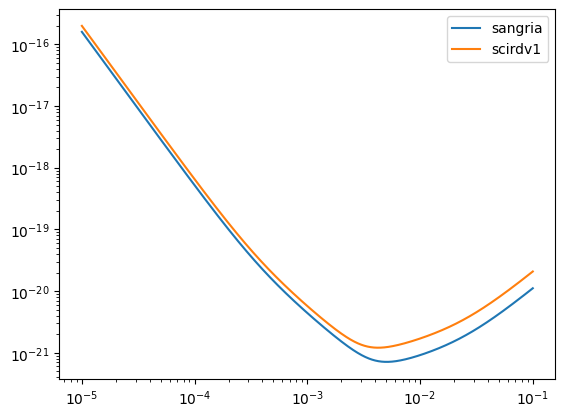

In [13]:
freq =np.logspace(-5, -1, 1000)
Sn_1 = get_sensitivity(freq, sens_fn=LISASens, average=True, model=lisa_models.sangria, return_type='char_strain')
Sn_2 = get_sensitivity(freq, sens_fn=LISASens, average=True, model=lisa_models.scirdv1, return_type='char_strain')

plt.loglog(freq, Sn_1, label="sangria")
plt.loglog(freq, Sn_2, label="scirdv1")
plt.legend()
plt.show()

In [14]:
Sn_1 = get_sensitivity(freq, sens_fn=LISASens, average=True, model=lisa_models.sangria, return_type='char_strain')

Sn_2 = get_sensitivity(freq, sens_fn=LISASens, average=False, model=lisa_models.sangria, return_type='char_strain')
# Sn_1/Sn_2

In [15]:
from lisatools.sensitivity import SensitivityMatrix, LISASens, A1TDISens, E1TDISens, T1TDISens

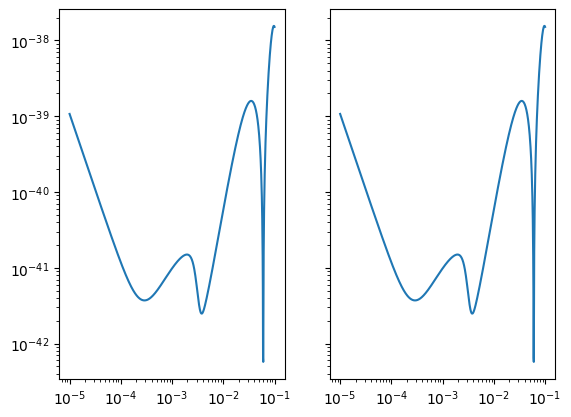

In [16]:
sens_kwargs = dict(
    stochastic_params=(1*YRSID_SI,)
)

sens_mat= SensitivityMatrix(freq,[A1TDISens,A1TDISens], **sens_kwargs)
sens_mat.loglog()
plt.show()

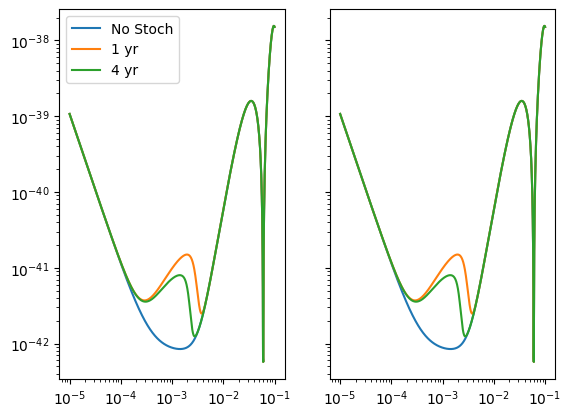

In [17]:
# clear (for internal clearing of answers)

sens_mat_no_confusion = deepcopy(sens_mat)
sens_mat_no_confusion.update_stochastic(stochastic_params=None)

sens_mat_1_yr = deepcopy(sens_mat)
sens_mat_1_yr.update_stochastic(stochastic_params=(1 * YRSID_SI,))

sens_mat_4_yr = deepcopy(sens_mat)
sens_mat_4_yr.update_stochastic(stochastic_params=(4 * YRSID_SI,))

fig, ax = sens_mat_no_confusion.loglog(label="No Stoch")

sens_mat_1_yr.loglog(fig=fig, ax=ax, label="1 yr")
sens_mat_4_yr.loglog(fig=fig, ax=ax, label="4 yr")
ax[0].legend()
plt.show()

In [18]:
dt=10
Tobs=1*YRSID_SI
Nobs=int(Tobs/dt)
t=np.arange(Nobs)*dt

In [19]:
# print(t)

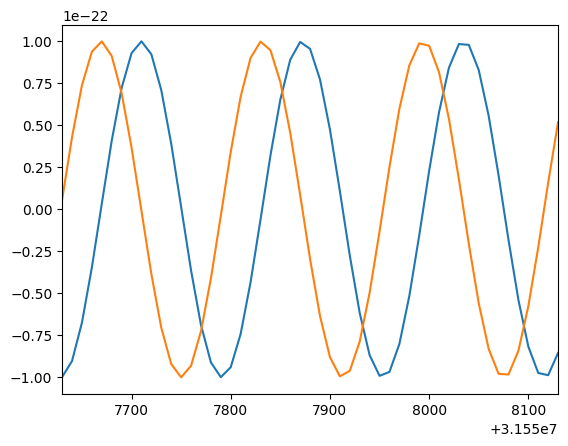

In [20]:
A = 1e-22
f0 = 3e-3
fdot = 1e-10
phi0 = 4.2

h1 = A * np.sin(2 * np.pi * (f0 * t + 1/2 * fdot * t ** 2) + phi0)
h2 = A * np.cos(2 * np.pi * (f0 * t + 1/2 * fdot * t ** 2) + phi0)
plt.plot(t, h1, label="h1")
plt.plot(t, h2, label="h2")
plt.xlim(t[-1] - 500.0, t[-1])
plt.show()


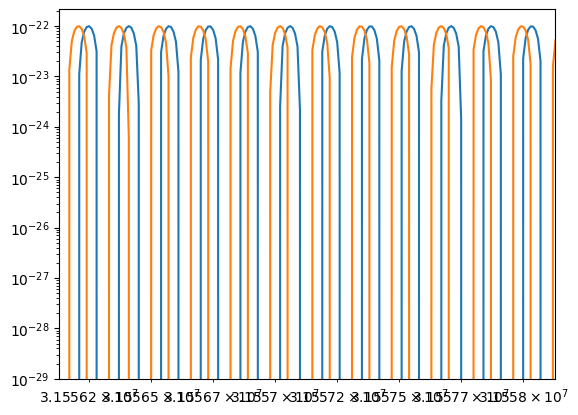

In [21]:
plt.loglog(t, h1, label="h1")
plt.loglog(t, h2, label="h2")
plt.xlim(t[-1] - 2000.0, t[-1])
plt.show()

In [22]:
from lisatools.datacontainer import DataResidualArray

In [23]:
data_res_arr= DataResidualArray([h1, h2], dt=dt)

In [24]:
# %matplotlib widget

In [25]:
# %matplotlib qt

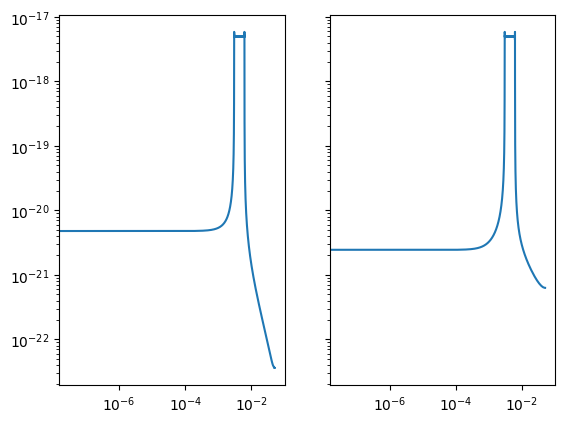

In [26]:
fig, ax = data_res_arr.loglog()
# ax[0].set_xlim(3e-3,4e-3)
# ax[1].set_xlim(3e-3,4e-3)
# ax[0].set_ylim(1e-18,1e-17)
# ax[1].set_ylim(1e-18,1e-17)
plt.show()
# %matplotlib qt

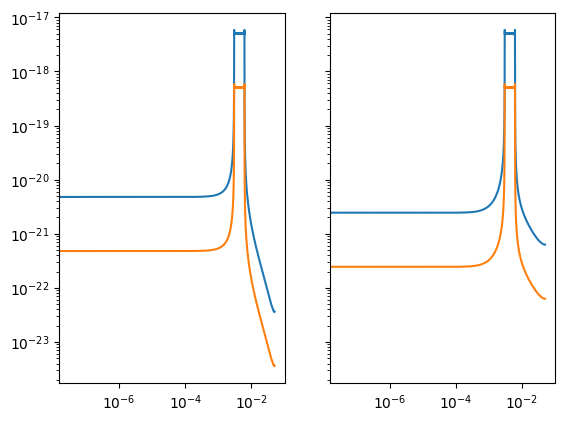

In [27]:
# clear (for internal clearing of answers)

fig, ax = data_res_arr.loglog()
h1_f = np.abs(np.fft.rfft(h1))
h2_f = np.abs(np.fft.rfft(h2))
ax[0].loglog(data_res_arr.f_arr, h1_f)
ax[1].loglog(data_res_arr.f_arr, h2_f)

In [28]:
np.abs(data_res_arr[0]) / h1_f

array([10., 10., 10., ..., 10., 10., 10.])

In [29]:
from lisatools.analysiscontainer import AnalysisContainer

(1e-24, 1e-18)

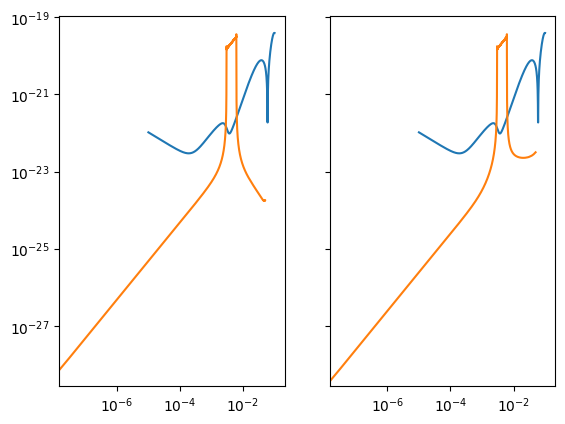

In [30]:
analysis = AnalysisContainer(data_res_arr, sens_mat)
fig, ax2 = analysis.loglog()
ax[0].set_ylim(1e-24,1e-18)

In [31]:
A_new = A # 1.01e-22
f0_new = f0 # 3.0000003e-3
fdot_new = fdot * (1.000001)
phi0_new = phi0  # 3.1

h1_new = A_new * np.sin(2 * np.pi * (f0_new * t + 1/2 * fdot_new * t ** 2) + phi0_new)
h2_new = A_new * np.cos(2 * np.pi * (f0_new * t + 1/2 * fdot_new * t ** 2) + phi0_new)

In [32]:
template = DataResidualArray([h1_new, h2_new], dt=dt)


In [33]:
sens_mat.update_frequency_arr(template.f_arr)

/usr/local/lib/python3.11/dist-packages/lisatools/detector.py:633: RuntimeWarning: divide by zero encountered in divide
  Sa_a = Sa_a_in * (1.0 + (0.4e-3 / frq) ** 2) * (1.0 + (frq / 8e-3) ** 4)
/usr/local/lib/python3.11/dist-packages/lisatools/detector.py:635: RuntimeWarning: divide by zero encountered in power
  Sa_d = Sa_a * (2.0 * np.pi * frq) ** (-4.0)
/usr/local/lib/python3.11/dist-packages/lisatools/detector.py:637: RuntimeWarning: invalid value encountered in multiply
  Sa_nu = Sa_d * (2.0 * np.pi * frq / C_SI) ** 2
/usr/local/lib/python3.11/dist-packages/lisatools/detector.py:642: RuntimeWarning: divide by zero encountered in divide
  Soms_d = Soms_d_in * (1.0 + (2.0e-3 / f) ** 4)
/usr/local/lib/python3.11/dist-packages/lisatools/detector.py:644: RuntimeWarning: invalid value encountered in multiply
  Soms_nu = Soms_d * (2.0 * np.pi * frq / C_SI) ** 2
/usr/local/lib/python3.11/dist-packages/lisatools/stochastic.py:178: RuntimeWarning: divide by zero encountered in power
  * (f

In [34]:
# why we aare dividing my sensitivity
# difference in template and nomal inner product
# is the inner product with itself is snr?

In [35]:
h_old_h_new = 4*template.df*np.real(np.sum(template[:,1:].conj()* data_res_arr[:,1:]/ sens_mat[:,1:]))

In [36]:
# h_old_h_new, h_old_h_new_same

In [37]:
analysis.inner_product()

158170.19293766312

In [38]:
analysis.template_inner_product(template)

157265.40056575954

In [39]:
hnew_hnew = 4 * template.df * np.real(np.sum(template[:, 1:].conj() * template[:, 1:] / sens_mat[:, 1:]))
print(hnew_hnew)
print(f"Opt SNR: {np.sqrt(hnew_hnew)}, Det SNR: {h_old_h_new / np.sqrt(hnew_hnew)}")

158169.98904394475
Opt SNR: 397.70590773075617, Det SNR: 395.4313916609635


In [40]:
opt_snr, det_snr = analysis.template_snr(template)
print(f"Opt SNR: {opt_snr}, Det SNR: {det_snr}")

Opt SNR: 397.7059077307561, Det SNR: 395.4313916609633


In [41]:
r1 = h1_new - h1
r2 = h2_new - h2

residual = DataResidualArray([r1, r2], dt=dt)

In [42]:
analysis_res = AnalysisContainer(residual, sens_mat)

In [43]:
print(analysis_res.inner_product())

1809.3808500887071


In [44]:
likelihood = -1/2 * analysis_res.inner_product()
print(f"Likelihoood: {likelihood}")

Likelihoood: -904.6904250443536


In [45]:
analysis.template_likelihood(template)


np.float64(-904.6904250443622)

In [46]:
def sinusoidal_waveform(A: float, f0: float, fdot: float, phi0: float, t: np.ndarray, **kwargs) -> [np.ndarray, np.ndarray]:
    h1 = A * np.sin(2 * np.pi * (f0 * t + 1/2 * fdot * t ** 2) + phi0)
    h2 = A * np.cos(2 * np.pi * (f0 * t + 1/2 * fdot * t ** 2) + phi0)
    return [h1, h2]

In [47]:
analysis.signal_gen = sinusoidal_waveform #(*args, **kwargs)

In [48]:

analysis.calculate_signal_likelihood( A*1.01, f0*1.00, fdot, phi0, t, source_only=True)

np.float64(-7.908509647008032)

# Calculations

## functions

In [49]:
from few.utils.geodesic import get_separatrix

In [50]:
from few.waveform import GenerateEMRIWaveform
few_gen = GenerateEMRIWaveform(
    "FastKerrEccentricEquatorialFlux",
    sum_kwargs=dict(pad_output=True, output_type="td"),
    inspiral_kwargs=dict(integrate_backwards=True),
    return_list=True,
)

DEBUG:few:Configuration file not found in '/content/few.ini'
DEBUG:few:Configuration file not found in '/root/.config/few.ini'
DEBUG:few:Configuration file not found in '/etc/xdg/few/v2.0/few.ini'
DEBUG:few:ConfigInitialization: final configuration entries are
DEBUG:few: ignore_cfg=False (from: ConfigSource.DEFAULT)
DEBUG:few: ignore_env=False (from: ConfigSource.DEFAULT)
DEBUG:few: config_file=None (from: ConfigSource.DEFAULT)
DEBUG:few: log_level=30 (from: ConfigSource.DEFAULT)
DEBUG:few: log_format=None (from: ConfigSource.DEFAULT)
DEBUG:few: file_registry_path=None (from: ConfigSource.DEFAULT)
DEBUG:few: file_storage_path=None (from: ConfigSource.DEFAULT)
DEBUG:few: file_download_path=None (from: ConfigSource.DEFAULT)
DEBUG:few: file_allow_download=True (from: ConfigSource.DEFAULT)
DEBUG:few: file_integrity_check=once (from: ConfigSource.DEFAULT)
DEBUG:few: file_extra_paths=[PosixPath('/usr/local/lib/python3.11/dist-packages/few/data')] (from: ConfigSource.DEFAULT)
DEBUG:few: file_

In [ ]:
from lisatools.sources.emri import EMRITDIWaveform
emri_lisa = EMRITDIWaveform(T=1., dt=10.,
    response_kwargs=dict(tdi_chan="AET", tdi="1st generation"),
    emri_waveform_kwargs=dict(inspiral_kwargs=dict(integrate_backwards=True)),
)


In [ ]:
def run_emri(func=emri_lisa, **params):
    return func(
        params['M'], params['mu'], params['a'], params['p0'], params['e0'], params['x0'], params['dist'],
        params['qS'], params['phiS'], params['qK'], params['phiK'],
        params['Phi_phi0'], params['Phi_theta0'], params['Phi_r0'],
        T=params['T'], dt=params['dt']
    )


## Analysis

In [ ]:
parameters = {
    'T': 1,  # duration in years
    'dt': 10.0,  # timestep in seconds
    'M': 1e6,  # primary mass
    'a': 0.8,  # spin, ignored in Schwarzschild waveform
    'mu': 1e3,  # secondary mass
    'p0': 16,  # initial semi-latus rectum
    'e0': .3,  # initial eccentricity
    'x0': 1.0,  # initial frequency param, ignored in Schwarzschild
    'qK': 0.0,  # polar spin angle
    'phiK': 0,  # azimuthal spin angle
    'qS': 0.3,  # polar sky angle
    'phiS': 0.3,  # azimuthal sky angle
    'dist': 1.0,  # luminosity distance in Gpc
    'Phi_phi0': 0.0,  # initial phase
    'Phi_theta0': 0.0,
    'Phi_r0': 0.0,
    'dt': 10.,
}
a=parameters['a']
e0=parameters['e0']
x0=parameters['x0']
parameters['p0'] = .05+ get_separatrix(a, e0, x0)

In [ ]:
waveform=run_emri(func=few_gen, **parameters)

In [ ]:
plt.plot(np.arange(len(waveform[0]))*10,waveform[0][::-1])
# plt.xlim(1.4e7,1.401e7)


In [ ]:
waveform_res=run_emri(**parameters)

In [ ]:
dt = 10  # or params['dt']
labels = ["A channel", "E channel", "T channel"]

fig, axes = plt.subplots(len(waveform_res), 1, figsize=(8, 6), sharex=True)

for i, ax in enumerate(axes):
    time = np.arange(len(waveform_res[i])) * dt
    signal = waveform_res[i][::-1]
    ax.plot(time, signal, label=labels[i])

    ax.set_ylabel("Strain")
    ax.legend()
    ax.grid(True)
    # ax.set_xlim(2.899e7,2.9e7)

axes[-1].set_xlabel("Time [s]")
plt.tight_layout()
plt.show()


In [ ]:
# freq =np.logspace(-5, -1, 1000)

# Build DataResidualArray (make sure shape is (n_chan, N))
data_arr = DataResidualArray(waveform_res, dt=10)

sens_kwargs = dict(
    stochastic_params=(4*YRSID_SI,)
)

sens_mat= SensitivityMatrix(data_arr.frequency_arr, [A1TDISens,E1TDISens,T1TDISens], **sens_kwargs)




# Pass it into AnalysisContainer
analysis_emri = AnalysisContainer(data_arr, sens_mat=sens_mat, signal_gen=run_emri)



In [ ]:
# Build DataResidualArray (make sure shape is (n_chan, N))
data_arr = DataResidualArray(waveform_res, dt=10)

# Pass it into AnalysisContainer
analysis_emri = AnalysisContainer(data_arr, sens_mat=sens_mat, signal_gen=run_emri)


In [ ]:
analysis_emri.loglog()

In [ ]:
analysis_emri.snr()

In [ ]:
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux


In [ ]:
traj_model = EMRIInspiral(func=KerrEccEqFlux)

In [ ]:
rhs_kerr = KerrEccEqFlux()
spin = 0.8

p_lim_check = np.linspace(4., 20, 101)
e_max = np.asarray([rhs_kerr.max_e(p_here, a=spin) for p_here in p_lim_check])
plt.plot(p_lim_check, e_max)
plt.xlabel("Semi-latus rectum")
plt.ylabel("Maximum eccentricity")

In [ ]:
traj_keys = ['M','mu','a','p0','e0','x0']

T=1.0
traj_pars = [parameters[k] for k in traj_keys]

In [ ]:
# traj_pars = {k: parameters[k] for k in traj_keys if k in parameters}
print(traj_pars)

In [ ]:
t, p, e, xI, Phi_phi, Phi_theta, Phi_r = traj_model(*traj_pars, T=T)


fig, axes = plt.subplots(2, 3)
plt.subplots_adjust(wspace=0.35)
fig.set_size_inches(14, 8)
axes = axes.ravel()

ylabels = [r"$e$", r"$p$", r"$e$", r"$\Phi_\phi$", r"$\Phi_\theta$", r"$\Phi_r$"]
xlabels = [r"$p$", r"$t$", r"$t$", r"$t$", r"$t$", r"$t$"]
ys = [e, p, e, Phi_phi, Phi_theta, Phi_r]
xs = [p, t, t, t, t, t]

for i, (ax, x, y, xlab, ylab) in enumerate(zip(axes, xs, ys, xlabels, ylabels)):
    ax.plot(x, y)
    ax.set_xlabel(xlab, fontsize=16)
    ax.set_ylabel(ylab, fontsize=16)

In [ ]:
new_wave = np.pad(waveform_res, pad_width=(0, 1000))  # 1D waveform
dt = 10

for cut in [0, 100, 500, 900, 950, 975, 990, 1000, 1100, 1500, 2000, 5000]:
    wave = new_wave[:-cut] if cut != 0 else new_wave  # avoid slicing to empty
    plt.figure()
    plt.plot(np.arange(len(wave[0])) * dt, wave[0])
    plt.title(f"Waveform cut: {cut}")
    plt.xlabel("Time [s]")
    plt.ylabel("Strain")
    plt.grid(True)
    plt.show()

    # Assuming it expects shape (channels, time)
    data_res_arr = DataResidualArray(wave[0], dt=dt)
    data_res_arr.loglog()
